In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [2]:
CONFIGS = [
    ("pixtral-coco-top_p-ft-listener_shuffle.jsonl", {
        "speaker": "pixtral",
        "listener": "pixtral",
        "speaker_ft": False,
        "listener_ft": True,
        "listener_shuffle": True,
        "listener_resolution": "full"
    }),
    ("pixtral-coco-top_p-ft-listener_shuffle-lowres.jsonl", {
        "speaker": "pixtral",
        "listener": "pixtral",
        "speaker_ft": False,
        "listener_ft": True,
        "listener_shuffle": True,
        "listener_resolution": "low"
    }),
    ("pixtral-coco-top_p.jsonl", {
        "speaker": "pixtral",
        "listener": "pixtral",
        "speaker_ft": False,
        "listener_ft": False,
        "listener_shuffle": True,
        "listener_resolution": "full"
    }),
    ("pixtral-coco-top_p-listener_no_shuffle.jsonl", {
        "speaker": "pixtral",
        "listener": "pixtral",
        "speaker_ft": False,
        "listener_ft": False,
        "listener_shuffle": False,
        "listener_resolution": "full"
    }),
    ("pixtral-coco-ft-top_p-listener_no_shuffle-human_speaker.jsonl", {
        "speaker": "human",
        "listener": "pixtral",
        "speaker_ft": False,
        "listener_ft": True,
        "listener_shuffle": False,
        "listener_resolution": "low"
    }),
    ("pixtral-coco-top_p-listener_no_shuffle-human_speaker.jsonl", {
        "speaker": "human",
        "listener": "pixtral",
        "speaker_ft": False,
        "listener_ft": False,
        "listener_shuffle": False,
        "listener_resolution": "low"
    }),
    ("pixtral-coco-ft-top_p-listener_shuffle-human_speaker.jsonl", {
        "speaker": "human",
        "listener": "pixtral",
        "speaker_ft": False,
        "listener_ft": True,
        "listener_shuffle": True,
        "listener_resolution": "low"
    }),
    ("pixtral-coco-top_p-listener_shuffle-human_speaker.jsonl", {
        "speaker": "human",
        "listener": "pixtral",
        "speaker_ft": False,
        "listener_ft": False,
        "listener_shuffle": True,
        "listener_resolution": "low"
    }),
]

In [3]:
dfs = list()
for i, (k, v) in enumerate(CONFIGS):
    df = pd.read_json(f"../simulate_sampling_results/{k}", lines=True, orient="records")
    df[[*v.keys(), "config_idx"]] = df.apply(lambda x: {**v, "config_idx": i}, axis=1, result_type="expand")
    dfs.append(df)

df = pd.concat(dfs)
df["block_idx"] = df.apply(lambda x: x['trial_idx'] // 4, axis=1)

In [ ]:
df.columns

In [4]:
def dictionary_softmax(d):
    denom = sum(np.exp(v) for v in d.values())
    return {k: np.exp(v) / denom for k, v in d.items()}

def mix_logits(d1, d2, alpha=0):
    return {k: (1 + alpha) * d1[k] - alpha * d2[k] for k in d1.keys()}

In [5]:
df = df.explode(
    [
        "sampled_descriptions",
        "sampled_descriptions_interpretations",
        "sampled_descriptions_interpretations_no_context",
        "ablated_descriptions",
        "ablated_descriptions_interpretations",
        "ablated_descriptions_interpretations_no_context",
    ]
)

In [6]:
df["sampled_descriptions_len"] = df.apply(lambda x: len(x["sampled_descriptions"].split()), axis=1)
df["ablated_descriptions_len"] = df.apply(lambda x: len(x["ablated_descriptions"].split()), axis=1)

In [7]:
df["sampled_descriptions_target_prob"] = df.apply(lambda x: dictionary_softmax(x["sampled_descriptions_interpretations"])[x['target']], axis=1)
df["sampled_descriptions_correct"] = df.apply(lambda x: max(x["sampled_descriptions_interpretations"], key=x["sampled_descriptions_interpretations"].get) == x['target'], axis=1)
df["sampled_descriptions_no_context_target_prob"] = df.apply(lambda x: dictionary_softmax(x["sampled_descriptions_interpretations_no_context"])[x['target']], axis=1)
df["sampled_descriptions_no_context_correct"] = df.apply(lambda x: max(x["sampled_descriptions_interpretations_no_context"], key=x["sampled_descriptions_interpretations_no_context"].get) == x['target'], axis=1)

In [8]:
df["ablated_descriptions_target_prob"] = df.apply(lambda x: dictionary_softmax(x["ablated_descriptions_interpretations"])[x['target']], axis=1)
df["ablated_descriptions_correct"] = df.apply(lambda x: max(x["ablated_descriptions_interpretations"], key=x["ablated_descriptions_interpretations"].get) == x['target'], axis=1)
df["ablated_descriptions_no_context_target_prob"] = df.apply(lambda x: dictionary_softmax(x["ablated_descriptions_interpretations_no_context"])[x['target']], axis=1)
df["ablated_descriptions_no_context_correct"] = df.apply(lambda x: max(x["ablated_descriptions_interpretations_no_context"], key=x["ablated_descriptions_interpretations_no_context"].get) == x['target'], axis=1)

In [9]:
df["tiled_description_target_prob"] = df.apply(lambda x: dictionary_softmax(x["tiled_description_interpretations"])[x['target']], axis=1)
df["tiled_description_correct"] = df.apply(lambda x: max(x["tiled_description_interpretations"], key=x["tiled_description_interpretations"].get) == x['target'], axis=1)

In [23]:
CONFIGS[5]

('pixtral-coco-top_p-listener_no_shuffle-human_speaker.jsonl',
 {'speaker': 'human',
  'listener': 'pixtral',
  'speaker_ft': False,
  'listener_ft': False,
  'listener_shuffle': False,
  'listener_resolution': 'low'})

Text(0, 0.5, 'Accuracy on human descriptions')

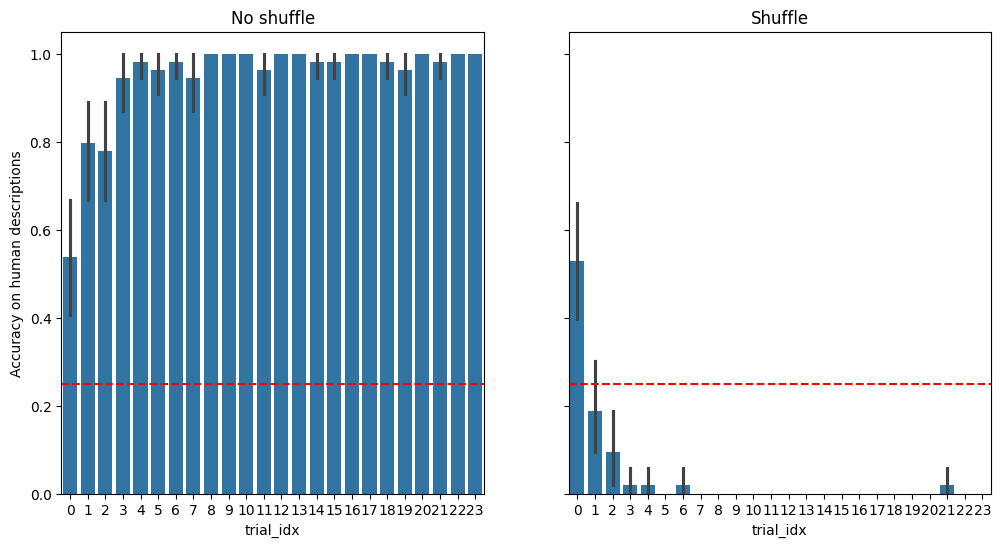

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df[df.config_idx == 5], x="trial_idx", y="sampled_descriptions_correct", ax=ax1)
# draw horizontal line at y=0.25
ax1.axhline(0.25, color='red', linestyle='--')
ax1.set_title("No shuffle")
ax1.set_ylabel("Accuracy on human descriptions")
sns.barplot(data=df[df.config_idx == 7], x="trial_idx", y="sampled_descriptions_correct", ax=ax2)
ax2.axhline(0.25, color='red', linestyle='--')
ax2.set_title("Shuffle")
ax2.set_ylabel("Accuracy on human descriptions")

Text(0, 0.5, 'Accuracy on human descriptions')

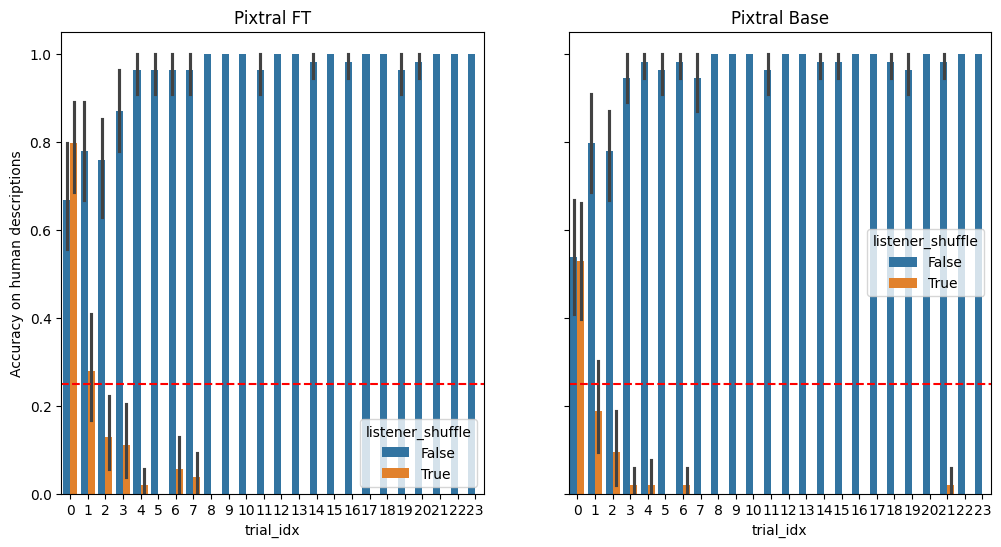

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df[df.config_idx.isin([4, 6])], x="trial_idx", y="sampled_descriptions_correct", ax=ax1, hue="listener_shuffle")
# draw horizontal line at y=0.25
ax1.axhline(0.25, color='red', linestyle='--')
ax1.set_title("Pixtral FT")
ax1.set_ylabel("Accuracy on human descriptions")
sns.barplot(data=df[df.config_idx.isin([5, 7])], x="trial_idx", y="sampled_descriptions_correct", ax=ax2, hue="listener_shuffle")
ax2.axhline(0.25, color='red', linestyle='--')
ax2.set_title("Pixtral Base")
ax2.set_ylabel("Accuracy on human descriptions")

Text(0, 0.5, 'Accuracy on human descriptions without prior conversation')

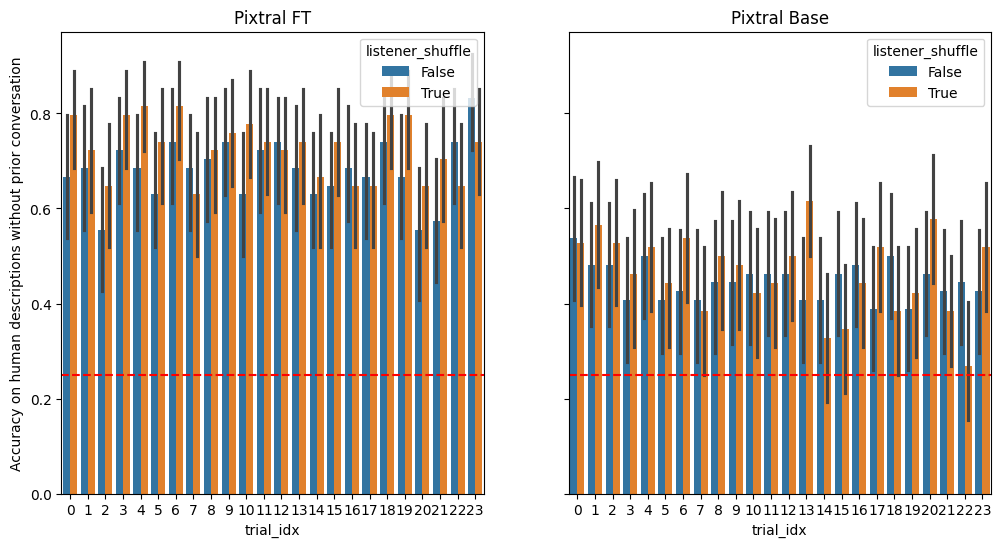

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df[df.config_idx.isin([4, 6])], x="trial_idx", y="sampled_descriptions_no_context_correct", ax=ax1, hue="listener_shuffle")
# draw horizontal line at y=0.25
ax1.axhline(0.25, color='red', linestyle='--')
ax1.set_title("Pixtral FT")
ax1.set_ylabel("Accuracy on human descriptions without prior conversation")
sns.barplot(data=df[df.config_idx.isin([5, 7])], x="trial_idx", y="sampled_descriptions_no_context_correct", ax=ax2, hue="listener_shuffle")
ax2.axhline(0.25, color='red', linestyle='--')
ax2.set_title("Pixtral Base")
ax2.set_ylabel("Accuracy on human descriptions without prior conversation")

Text(0, 0.5, 'Accuracy on Pixtral descriptions')

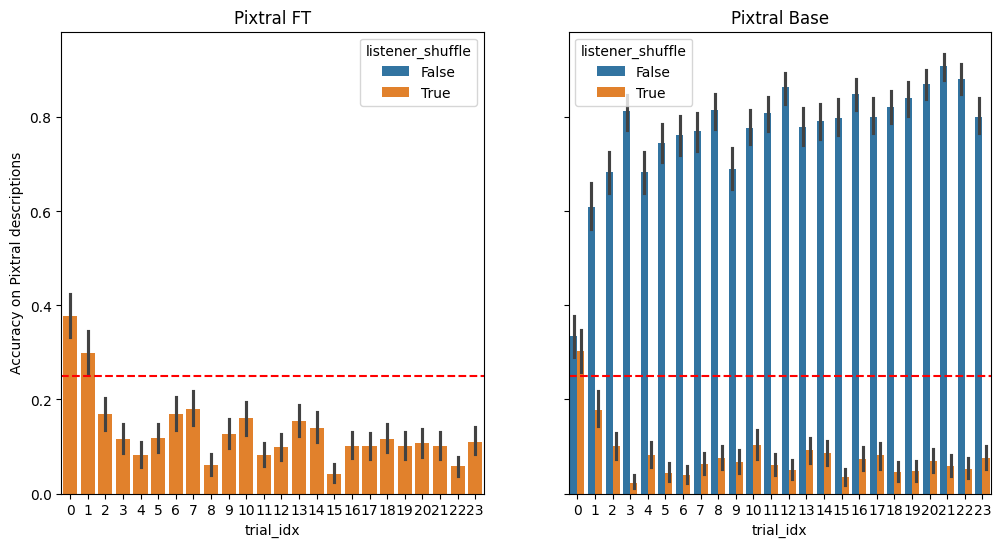

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df[df.config_idx.isin([0])], x="trial_idx", y="sampled_descriptions_correct", ax=ax1, hue="listener_shuffle", hue_order=[False, True])
# draw horizontal line at y=0.25
ax1.axhline(0.25, color='red', linestyle='--')
ax1.set_title("Pixtral FT")
ax1.set_ylabel("Accuracy on Pixtral descriptions")
sns.barplot(data=df[df.config_idx.isin([2, 3])], x="trial_idx", y="sampled_descriptions_correct", ax=ax2, hue="listener_shuffle", hue_order=[False, True])
ax2.axhline(0.25, color='red', linestyle='--')
ax2.set_title("Pixtral Base")
ax2.set_ylabel("Accuracy on Pixtral descriptions")

Text(0, 0.5, 'Accuracy on Pixtral descriptions')

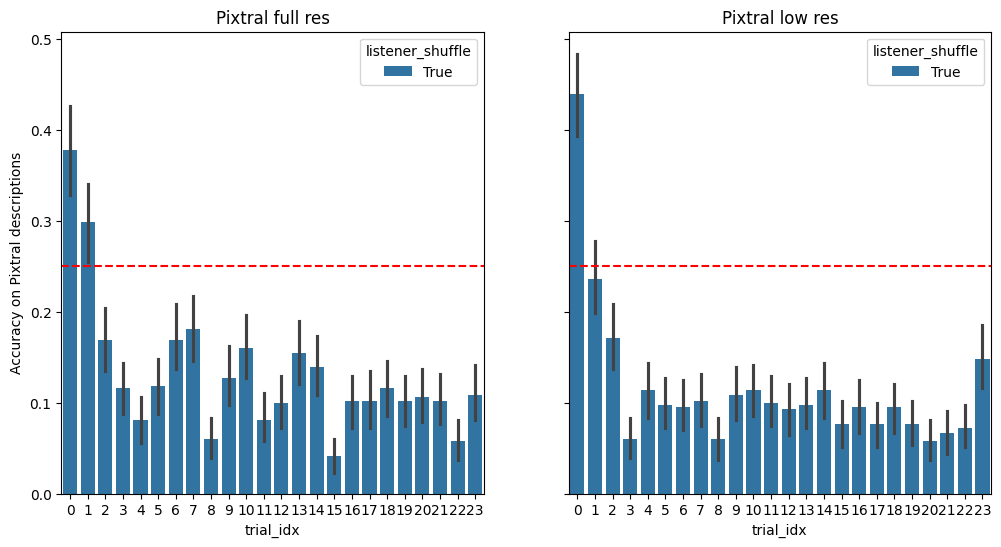

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=df[df.config_idx.isin([0])], x="trial_idx", y="sampled_descriptions_correct", ax=ax1, hue="listener_shuffle")
# draw horizontal line at y=0.25
ax1.axhline(0.25, color='red', linestyle='--')
ax1.set_title("Pixtral full res")
ax1.set_ylabel("Accuracy on Pixtral descriptions")
sns.barplot(data=df[df.config_idx.isin([1])], x="trial_idx", y="sampled_descriptions_correct", ax=ax2, hue="listener_shuffle")
ax2.axhline(0.25, color='red', linestyle='--')
ax2.set_title("Pixtral low res")
ax2.set_ylabel("Accuracy on Pixtral descriptions")

In [ ]:
sns.barplot(data=df, x="block_idx", y="tiled_description_correct", hue="sampling_method")

In [ ]:
sns.barplot(data=df, x="trial_idx", y="tiled_description_correct", hue="sampling_method")

In [ ]:
mean_agg_df = df.groupby(
    [
        "speaker_model",
        "speaker_sampling_method",
        "gameid",
        "trial_idx",
        "target",
        "block_idx",
    ]
).agg(
    {
        "sampled_descriptions_correct": "mean",
        "sampled_descriptions_no_context_correct": "mean",
        "ablated_descriptions_correct": "mean",
        "ablated_descriptions_no_context_correct": "mean",
        "tiled_description_correct": "mean",
    }
).reset_index()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="sampled_descriptions_correct", ax=ax1)
ax1.set_title("Sampled Descriptions")
ax1.set_ylabel("Accuracy")
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="ablated_descriptions_correct", ax=ax2)
ax2.set_title("Ablated Descriptions")
ax2.set_ylabel("Accuracy")

In [ ]:
max_agg_df = df.groupby(
    [
        "speaker_model",
        "speaker_sampling_method",
        "gameid",
        "trial_idx",
        "target",
        "block_idx"
    ]
).agg(
    {
        "sampled_descriptions_correct": "max",
        "sampled_descriptions_no_context_correct": "max",
        "ablated_descriptions_correct": "max",
        "ablated_descriptions_no_context_correct": "max",
        "tiled_description_correct": "max",
    }
).reset_index()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="sampled_descriptions_correct", ax=ax1)
ax1.set_title("Mean accuracy")
ax1.set_ylabel("Accuracy")
sns.barplot(data=max_agg_df[max_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="sampled_descriptions_correct", ax=ax2)
ax2.set_title("Max accuracy")
ax2.set_ylabel("Accuracy")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="block_idx", y="sampled_descriptions_correct", ax=ax1)
ax1.set_title("Mean accuracy")
ax1.set_ylabel("Accuracy")
sns.barplot(data=max_agg_df[max_agg_df.speaker_sampling_method == "top_p"], x="block_idx", y="sampled_descriptions_correct", ax=ax2)
ax2.set_title("Max accuracy")
ax2.set_ylabel("Accuracy")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(data=mean_agg_df[mean_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="tiled_description_correct", ax=ax1)
ax1.set_title("Mean accuracy")
ax1.set_ylabel("Accuracy")
sns.barplot(data=max_agg_df[max_agg_df.speaker_sampling_method == "top_p"], x="trial_idx", y="tiled_description_correct", ax=ax2)
ax2.set_title("Max accuracy")
ax2.set_ylabel("Accuracy")

In [ ]:
df.gameid.unique()

In [ ]:
df[
    (df.gameid == "0788-0101405f-5745-4c8c-a882-d4eaf34b45fd")
    & (df.speaker_sampling_method == "top_p")
].groupby(
    [
        "speaker_model",
        "speaker_sampling_method",
        "selected_description",
        "gameid",
        "trial_idx",
        "target",
        "block_idx",
    ]
).agg(
    {
        "sampled_descriptions_correct": "mean",
        "ablated_descriptions_correct": "mean",
        "tiled_description_correct": "mean",
    }
).reset_index().sort_values(by='trial_idx')